# A Mini-GPT Language Model: Transformers vs. RNNs

In the previous module we trained an **RNN** to model Shakespearean English. The RNN reads its input one word at a time, maintaining a hidden state that summarises everything it has seen so far. That's elegant — it directly mirrors a discrete-time dynamical system — but it has two big practical problems:

1. **Sequential bottleneck.** Each step depends on the previous step's hidden state, so we can't parallelise across time. Training is slow.
2. **Vanishing/exploding gradients.** Gradients flow backwards through every time step, multiplying matrices repeatedly. Information from far-back tokens gets either washed out or blown up before it reaches the gradient update.

The **Transformer** architecture (Vaswani et al., 2017) solves both problems by removing recurrence entirely. Instead of stepping through time, every position can directly *attend* to every earlier position in parallel — a kind of learned weighted average across the entire history.

A physics analogy: an RNN is like *time-stepping a state vector* through a dynamical system. A Transformer is more like a **kernel smoother** or a **matched-filter bank** — for each query position, it computes a weighted sum over the whole history at once, with the weights determined by similarity. No recurrence, no sequential bottleneck, no gradient path through time.

By the end of this notebook you will have:
- Implemented **causal self-attention** from scratch (the core operation of the Transformer)
- Built a small **GPT-style language model** by stacking Transformer blocks
- Trained both the Transformer and a comparable RNN on the same Tiny Shakespeare data
- Compared their loss curves and their generated text
- Run a head-to-head experiment showing how each model handles short vs. longer context windows

## 1. Imports and Setup

Same minimal stack as in the previous two modules.

In [1]:
%matplotlib inline

import os
import math
import urllib.request
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import random

# Fix random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.2.2


## 2. Load and Tokenise the Text

We reuse the **exact same data pipeline** as Module 2: download Tiny Shakespeare, tokenise by lower-casing and splitting on whitespace, and cap the vocabulary at the most frequent 5,000 words.

Keeping these identical matters: when we compare the Transformer to the RNN later in the notebook, we want any difference to come from the architecture, *not* from a different dataset or vocabulary.

In [2]:
DATA_DIR = './data'
TEXT_PATH = os.path.join(DATA_DIR, 'tinyshakespeare.txt')
URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(TEXT_PATH):
    print(f"Downloading Tiny Shakespeare from {URL} ...")
    urllib.request.urlretrieve(URL, TEXT_PATH)
    print("Done.")
else:
    print("Text file already downloaded.")

with open(TEXT_PATH, 'r', encoding='utf-8') as f:
    raw_text = f.read()

# Tokenise: lower-case, split on whitespace (punctuation stays attached)
tokens = raw_text.lower().split()

# Cap vocabulary at the most frequent VOCAB_SIZE words; rest become <unk>
VOCAB_SIZE = 5000
word_counts = Counter(tokens)
most_common = word_counts.most_common(VOCAB_SIZE - 1)
idx_to_word = ['<unk>'] + [w for w, _ in most_common]
word_to_idx = {w: i for i, w in enumerate(idx_to_word)}
UNK_INDEX = 0

data_indices = [word_to_idx.get(w, 0) for w in tokens]
data_tensor = torch.tensor(data_indices, dtype=torch.long)

print(f"Total tokens     : {len(tokens):,}")
print(f"Vocabulary size  : {len(idx_to_word):,}")
print(f"<unk> fraction   : {(data_tensor == 0).float().mean().item():.1%}")

Text file already downloaded.
Total tokens     : 202,651
Vocabulary size  : 5,000
<unk> fraction   : 12.5%


## 3. Build Training Sequences

Same sliding-window setup as Module 2: for each window of length `seq_len`, the input is the first `seq_len` tokens and the target is the same sequence shifted by one. At every position the model predicts the next word given everything to its left.

We wrap the sequence-building logic in a function because we'll re-use it later when we compare different context lengths.

In [3]:
SEQ_LEN    = 20
BATCH_SIZE = 64

# 90/10 train/test split. Sequential data, so we split by position, not at random.
split = int(0.9 * len(data_tensor))
train_data = data_tensor[:split]
test_data  = data_tensor[split:]


def make_sequences(data, seq_len):
    """Slice `data` into overlapping (input, target) windows of length seq_len."""
    n_sequences = len(data) - seq_len
    inputs  = torch.zeros((n_sequences, seq_len), dtype=torch.long)
    targets = torch.zeros((n_sequences, seq_len), dtype=torch.long)
    for i in range(n_sequences):
        inputs[i]  = data[i     : i + seq_len]
        targets[i] = data[i + 1 : i + seq_len + 1]
    return inputs, targets


def make_loaders(seq_len, batch_size=BATCH_SIZE):
    """Build train/test DataLoaders for a given context length."""
    tr_in, tr_tg = make_sequences(train_data, seq_len)
    te_in, te_tg = make_sequences(test_data,  seq_len)
    tr_loader = DataLoader(TensorDataset(tr_in, tr_tg), batch_size=batch_size, shuffle=True)
    te_loader = DataLoader(TensorDataset(te_in, te_tg), batch_size=batch_size, shuffle=False)
    return tr_loader, te_loader


train_loader, test_loader = make_loaders(SEQ_LEN)

print(f"Training tokens   : {len(train_data):,}")
print(f"Test tokens       : {len(test_data):,}")
print(f"Training sequences: {len(train_loader.dataset):,}")

Training tokens   : 182,385
Test tokens       : 20,266
Training sequences: 182,365


## 4. Causal Self-Attention from First Principles

Self-attention is the **single new idea** in a Transformer. Everything else (embeddings, linear layers, residual connections, LayerNorm) is standard. Let's build attention from the ground up.

### The kernel-smoother analogy

Suppose we have a sequence of feature vectors $x_1, x_2, \ldots, x_T$, one per token. For each position $t$ we want to produce an *updated* feature vector $y_t$ that combines information from positions $1, \ldots, t$ (we are *not* allowed to peek at the future — that's the "causal" part).

The simplest sensible thing is a **weighted average**:

$$ y_t = \sum_{s \le t} \alpha_{t,s}\, x_s $$

where the weights $\alpha_{t,s}$ are non-negative and sum to 1. The art is in *how to compute the weights*. A kernel-density estimator would choose them based on some fixed similarity (e.g. a Gaussian in feature space). A Transformer learns them.

### Q, K, V — queries, keys, values

For each input vector $x_s$, the network computes **three** learned linear projections:
- **Query** $q_s = W_Q\, x_s$ — "what am I looking for at this position?"
- **Key** $k_s = W_K\, x_s$ — "what content do I advertise to others?"
- **Value** $v_s = W_V\, x_s$ — "what information do I contribute if someone matches me?"

> **Implementation note.** The math above writes each projection as just a matrix multiply, but `nn.Linear` in our code (`self.qkv = nn.Linear(embed_dim, 3 * embed_dim)`) adds a learnable **bias** vector by default: it actually computes $q_s = W_Q\, x_s + b_Q$, and similarly for $K$ and $V$. The original *Attention is All You Need* paper and GPT-2 both keep the bias; modern large models (GPT-3, LLaMA, PaLM) drop it with `bias=False`, partly for a tiny memory/FLOP saving and partly because some studies report slightly more stable training without it. At our scale the difference is negligible — we keep PyTorch's default and just want to flag the discrepancy between the equation and the code.

The attention weight from position $t$ (the query) to position $s$ (the key) is the **scaled dot product** of $q_t$ and $k_s$, passed through a softmax over $s$:

$$ \alpha_{t,s} = \frac{\exp\!\left(q_t \cdot k_s / \sqrt{d}\right)}{\sum_{s' \le t}\exp\!\left(q_t \cdot k_{s'} / \sqrt{d}\right)} $$

and the output is the weighted sum of *values*:

$$ y_t = \sum_{s \le t} \alpha_{t,s}\, v_s. $$

The $\sqrt{d}$ scaling — where $d$ is the dimensionality of each $q, k$ vector (which equals `head_dim = embed_dim // n_heads` in our implementation, *not* the full embedding dimension) — keeps the dot product from blowing up when $d$ is large. Without it, large $d$ would push the softmax into its saturated regime where almost all the weight piles on one position.

### The causal mask

We want position $t$ to attend only to positions $s \le t$ (the past, not the future). We enforce this by setting $q_t \cdot k_s = -\infty$ for $s > t$ before the softmax — those entries become exactly zero. This is the model's enforced "arrow of time."

### Multi-head attention

A single attention operation can only learn one notion of similarity. **Multi-head** attention runs $H$ parallel attention operations on different subspaces of the feature vector — each "head" can learn to track a different pattern (one head might track recent verbs, another might track who the current speaker is). The outputs of all heads are concatenated and projected back to the original size.

In [4]:
class CausalSelfAttention(nn.Module):
    """
    Multi-head causal self-attention.

    Each input position attends to itself and all earlier positions.
    The attention is split across `n_heads` independent heads, each working
    on a slice of size embed_dim // n_heads.
    """
    def __init__(self, embed_dim, n_heads, max_seq_len):
        super().__init__()
        assert embed_dim % n_heads == 0, \
            "embed_dim must be divisible by n_heads"

        self.embed_dim = embed_dim
        self.n_heads   = n_heads
        self.head_dim  = embed_dim // n_heads

        # One big linear layer that produces Q, K, V for all heads at once.
        # We split it apart inside forward(). It is equivalent to having three
        # separate nn.Linear(embed_dim, embed_dim) layers, but slightly faster.
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)

        # Projects the concatenated head outputs back to embed_dim
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        # Pre-compute the causal mask: a (max_seq_len x max_seq_len) lower-triangular
        # matrix of 1s. We register it as a buffer (not a parameter) so it moves with
        # the model across devices but isn't trained.
        # `register_buffer` is the standard PyTorch way to attach a constant tensor
        # to a module.
        causal_mask = torch.tril(torch.ones(max_seq_len, max_seq_len))
        self.register_buffer('causal_mask', causal_mask)

    def forward(self, x):
        """
        Parameters
        ----------
        x : FloatTensor of shape (batch, seq_len, embed_dim)

        Returns
        -------
        Tensor of shape (batch, seq_len, embed_dim)
        """
        B, T, C = x.shape   # batch, time, channels (= embed_dim)

        # Compute Q, K, V in one go, then split into three tensors of shape
        # (B, T, embed_dim) each.
        q, k, v = self.qkv(x).split(self.embed_dim, dim=-1)

        # Reshape so each head gets its own slice of the feature dimension.
        # New shape: (B, n_heads, T, head_dim).
        # The transpose puts n_heads before T so that the attention matmuls
        # work the same way for every head in parallel.
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention.
        # attn_scores[..., i, j] = q_i . k_j / sqrt(head_dim)
        # Shape: (B, n_heads, T, T)
        attn_scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # Apply the causal mask: any position j > i gets -inf, so after softmax
        # those weights become exactly zero. We take the top-left TxT slice of
        # our pre-built max_seq_len x max_seq_len mask.
        mask = self.causal_mask[:T, :T]
        attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))

        # Softmax over the keys (last dimension) gives us the attention weights
        attn_weights = F.softmax(attn_scores, dim=-1)

        # Weighted sum of values.  Shape: (B, n_heads, T, head_dim)
        y = attn_weights @ v

        # Concatenate heads back together. We transpose back to (B, T, n_heads, head_dim),
        # make the tensor contiguous in memory (required by view), then merge the
        # last two dims to get (B, T, embed_dim).
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        # Final output projection mixes information across heads.
        return self.out_proj(y)


# Quick sanity check: run a small random batch through the layer and verify shapes.
_attn = CausalSelfAttention(embed_dim=64, n_heads=4, max_seq_len=SEQ_LEN)
_x = torch.randn(2, SEQ_LEN, 64)
_y = _attn(_x)
print(f"Input shape : {tuple(_x.shape)}")
print(f"Output shape: {tuple(_y.shape)}   (should match input)")

Input shape : (2, 20, 64)
Output shape: (2, 20, 64)   (should match input)


## 5. The Transformer Block

A single Transformer block stacks two operations, each wrapped in a **residual connection** and preceded by **LayerNorm**:

In equation form, one block computes:

$$
\begin{aligned}
x_\text{mid} &= x_\text{in}  + \text{CausalSelfAttention}(\text{LayerNorm}(x_\text{in})) \\
x_\text{out} &= x_\text{mid} + \text{FeedForwardMLP}(\text{LayerNorm}(x_\text{mid}))
\end{aligned}
$$

That is, each sub-layer reads a *normalised* copy of its input, computes a correction, and adds that correction back to the original. The output of one block becomes the input of the next.

**Why residuals?** The residual path `output = input + correction` means the block starts out doing *almost nothing* (when the inner layers are near zero), and learns to add small corrections. This is the same idea as **perturbation theory** in physics — start from a known solution (the identity), add small adjustments. Practically, residuals make deep networks much easier to train because gradients flow straight back through the addition.

**Why LayerNorm?** It normalises each token's feature vector to have zero mean and unit variance across its features — analogous to z-scoring variables before fitting a regression. This keeps the inputs to each sub-layer on a consistent scale, which makes training more stable.

**The feed-forward MLP** is a per-position 2-layer network (with GELU non-linearity) that lets the model do more flexible transformations *within* a single position, after the attention has gathered information across positions. The hidden dimension is usually ~4× the embedding dimension.

In [5]:
class TransformerBlock(nn.Module):
    """One Transformer block: causal self-attention + feed-forward MLP,
    each with a residual connection and pre-LayerNorm."""
    def __init__(self, embed_dim, n_heads, max_seq_len, ffn_mult=4):
        super().__init__()
        self.ln1   = nn.LayerNorm(embed_dim)
        self.attn  = CausalSelfAttention(embed_dim, n_heads, max_seq_len)
        self.ln2   = nn.LayerNorm(embed_dim)
        # Two-layer feed-forward MLP with GELU. The hidden size is ffn_mult * embed_dim
        # (a common choice is ffn_mult=4).
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, ffn_mult * embed_dim),
            nn.GELU(),
            nn.Linear(ffn_mult * embed_dim, embed_dim),
        )

    def forward(self, x):
        # Each sub-layer is wrapped in a residual:  x = x + sub_layer(LayerNorm(x))
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

## 6. Positional Encodings

Pure self-attention is **permutation-invariant**: if we shuffle the input tokens, the attention weights between any pair would just shuffle along with them. "the cat sat on the mat" and "mat the on sat cat the" would look identical to a Transformer with no position information.

We fix this by giving every position its own learned vector and *adding* it to the token embedding. The model can then use these position vectors to figure out the order.

We use **learned positional embeddings** (`nn.Embedding(max_seq_len, embed_dim)`) — the simplest choice. Other options exist (sinusoidal, RoPE, ALiBi) and are common in modern Transformers, but they don't change the conceptual picture.

## 7. The Full Mini-GPT Model

Now we put it all together:

```
token indices  ->  token embedding
                 + positional embedding
                  ->  N x [TransformerBlock]
                  ->  final LayerNorm
                  ->  linear projection to vocab_size
                  ->  logits for next-word prediction
```

This is the same shape as the original GPT — just much smaller.

In [6]:
class MiniGPT(nn.Module):
    """
    A small decoder-only Transformer (GPT-style) language model.

    Parameters
    ----------
    vocab_size  : int   number of distinct token indices
    embed_dim   : int   dimensionality of token and position embeddings
    n_heads     : int   number of attention heads per block
    n_layers    : int   number of stacked Transformer blocks
    max_seq_len : int   maximum context length we'll ever process
    """
    def __init__(self, vocab_size, embed_dim=48, n_heads=4, n_layers=2,
                 max_seq_len=SEQ_LEN):
        super().__init__()
        self.vocab_size  = vocab_size
        self.max_seq_len = max_seq_len

        # Two embedding tables: one for the token identity, one for its position.
        # They get added together to form the input to the Transformer blocks.
        self.token_emb = nn.Embedding(vocab_size,  embed_dim)
        self.pos_emb   = nn.Embedding(max_seq_len, embed_dim)

        # Stack of Transformer blocks. nn.ModuleList registers each one so its
        # parameters show up in model.parameters().
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, n_heads, max_seq_len)
            for _ in range(n_layers)
        ])

        # Final LayerNorm + projection to vocabulary logits
        self.ln_f   = nn.LayerNorm(embed_dim)
        self.output = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        """
        x : LongTensor of shape (batch, seq_len) — word indices.

        Returns logits of shape (batch, seq_len, vocab_size).
        """
        B, T = x.shape
        assert T <= self.max_seq_len, \
            f"Input length {T} exceeds max_seq_len={self.max_seq_len}"

        # Token embeddings: (B, T, embed_dim)
        tok = self.token_emb(x)

        # Position embeddings: take rows 0..T-1 from the position table.
        # torch.arange(T) gives [0, 1, ..., T-1].
        # Result shape: (T, embed_dim), which broadcasts across the batch.
        pos_ids = torch.arange(T, device=x.device)
        pos = self.pos_emb(pos_ids)

        h = tok + pos

        # Run through each Transformer block in turn
        for block in self.blocks:
            h = block(h)

        h = self.ln_f(h)
        return self.output(h)


# Build a default Mini-GPT and count its parameters
gpt_model = MiniGPT(vocab_size=VOCAB_SIZE, embed_dim=48, n_heads=4, n_layers=2,
                    max_seq_len=SEQ_LEN)
n_params = sum(p.numel() for p in gpt_model.parameters())
print(gpt_model)
print(f"\nMini-GPT trainable parameters: {n_params:,}")

MiniGPT(
  (token_emb): Embedding(5000, 48)
  (pos_emb): Embedding(20, 48)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (ln1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=48, out_features=144, bias=True)
        (out_proj): Linear(in_features=48, out_features=48, bias=True)
      )
      (ln2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=48, out_features=192, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=192, out_features=48, bias=True)
      )
    )
  )
  (ln_f): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
  (output): Linear(in_features=48, out_features=5000, bias=True)
)

Mini-GPT trainable parameters: 542,600


## 8. A Reference RNN for Comparison

To compare apples-to-apples, we re-declare the same RNN language model from Module 2 here. Same `embed_dim=32`, `hidden_dim=64` defaults, same training loop. This keeps the notebook self-contained — you don't have to have Module 2 already run.

One small difference: Module 2's RNN returned `(logits, hidden)` so that generation could carry the hidden state forward and avoid recomputing. Here we drop the hidden-state return and just return `logits`, so the RNN has the **same call signature as `MiniGPT`** and the same `train()` / `evaluate()` / `complete_sentence()` functions work for both.

In [7]:
class RNNLanguageModel(nn.Module):
    """Same plain word-level RNN as Module 2."""
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64, n_layers=1):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding  = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim,
                          num_layers=n_layers, nonlinearity='tanh',
                          batch_first=True)
        self.output = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, hidden = self.rnn(emb, hidden)
        return self.output(out)  # we drop the hidden-state return here for uniformity


rnn_model = RNNLanguageModel(vocab_size=VOCAB_SIZE)
rnn_n_params = sum(p.numel() for p in rnn_model.parameters())
print(rnn_model)
print(f"\nRNN trainable parameters    : {rnn_n_params:,}")
print(f"Mini-GPT trainable parameters: {n_params:,}")
print(f"\nThe Mini-GPT is about {n_params / rnn_n_params:.1f}x larger than the RNN.")

RNNLanguageModel(
  (embedding): Embedding(5000, 32)
  (rnn): RNN(32, 64, batch_first=True)
  (output): Linear(in_features=64, out_features=5000, bias=True)
)

RNN trainable parameters    : 491,272
Mini-GPT trainable parameters: 542,600

The Mini-GPT is about 1.1x larger than the RNN.


## 9. Training Loop

Same loss (cross-entropy), same optimiser (Adam), same gradient clipping, same per-token evaluation. The only quirk is that both models return logits of shape `(batch, seq_len, vocab_size)`, so we can use one training function for both.

In [8]:
def evaluate(model, loader):
    """Return mean cross-entropy loss per token on the given dataset."""
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='sum')
    total_loss   = 0.0
    total_tokens = 0
    with torch.no_grad():
        for inputs, targets in loader:
            logits = model(inputs)
            loss = criterion(
                logits.reshape(-1, model.vocab_size),
                targets.reshape(-1),
            )
            total_loss   += loss.item()
            total_tokens += targets.numel()
    return total_loss / total_tokens


def train(model, train_loader, test_loader, n_epochs=3, lr=0.002,
          clip=1.0, verbose=True, label="model"):
    """
    Train `model` and return per-epoch (train_loss, test_loss) lists.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches  = 0

        for inputs, targets in train_loader:
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(
                logits.reshape(-1, model.vocab_size),
                targets.reshape(-1),
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1

        tr = epoch_loss / n_batches
        te = evaluate(model, test_loader)
        train_losses.append(tr)
        test_losses.append(te)

        if verbose:
            print(f"[{label}]  Epoch {epoch + 1:2d}/{n_epochs}  |  "
                  f"Train loss: {tr:.3f} (ppl {np.exp(tr):6.1f})  |  "
                  f"Test loss: {te:.3f} (ppl {np.exp(te):6.1f})")

    return train_losses, test_losses

## 10. Train Both Models on the Same Data

We train both models for the same number of epochs (`n_epochs=3`) on the same DataLoader with the same context length (`seq_len=20`). We've also tuned the Mini-GPT's `embed_dim` so that its total parameter count is comparable to the RNN's — that way any difference in test loss reflects the architecture, not just "the Transformer has more knobs to learn with."

> **Heads up on runtime.** Each Mini-GPT batch involves substantially more arithmetic than each RNN batch (the 4× feed-forward expansion and stacked blocks add up). On a typical laptop CPU the Mini-GPT will probably be **slower per batch** than the RNN, despite its parallelism — the per-position parallelism that makes Transformers so attractive really pays off on GPUs, not CPUs. Expect roughly 10–20 minutes per model.

In [9]:
# Fresh models, identical training setup
rnn_model = RNNLanguageModel(vocab_size=VOCAB_SIZE)
gpt_model = MiniGPT(vocab_size=VOCAB_SIZE, embed_dim=48, n_heads=4,
                    n_layers=2, max_seq_len=SEQ_LEN)

print("=== Training RNN ===")
rnn_train, rnn_test = train(rnn_model, train_loader, test_loader,
                             n_epochs=3, label="RNN")

print("\n=== Training Mini-GPT ===")
gpt_train, gpt_test = train(gpt_model, train_loader, test_loader,
                             n_epochs=3, label="GPT")

=== Training RNN ===
[RNN]  Epoch  1/3  |  Train loss: 5.265 (ppl  193.4)  |  Test loss: 5.688 (ppl  295.3)
[RNN]  Epoch  2/3  |  Train loss: 4.492 (ppl   89.3)  |  Test loss: 6.006 (ppl  405.7)
[RNN]  Epoch  3/3  |  Train loss: 4.184 (ppl   65.6)  |  Test loss: 6.306 (ppl  547.9)

=== Training Mini-GPT ===
[GPT]  Epoch  1/3  |  Train loss: 4.980 (ppl  145.5)  |  Test loss: 5.944 (ppl  381.5)
[GPT]  Epoch  2/3  |  Train loss: 4.167 (ppl   64.6)  |  Test loss: 6.521 (ppl  679.4)
[GPT]  Epoch  3/3  |  Train loss: 3.849 (ppl   46.9)  |  Test loss: 6.963 (ppl 1057.2)


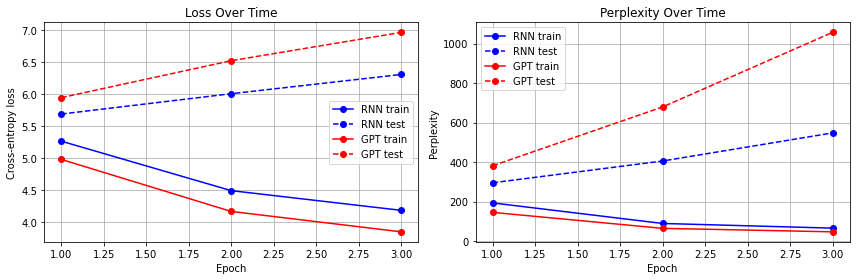

In [10]:
# Plot both models' loss curves side by side
epochs = range(1, len(rnn_train) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, rnn_train, 'b-o',  label='RNN train')
ax1.plot(epochs, rnn_test,  'b--o', label='RNN test')
ax1.plot(epochs, gpt_train, 'r-o',  label='GPT train')
ax1.plot(epochs, gpt_test,  'r--o', label='GPT test')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('Loss Over Time')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, np.exp(rnn_train), 'b-o',  label='RNN train')
ax2.plot(epochs, np.exp(rnn_test),  'b--o', label='RNN test')
ax2.plot(epochs, np.exp(gpt_train), 'r-o',  label='GPT train')
ax2.plot(epochs, np.exp(gpt_test),  'r--o', label='GPT test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity')
ax2.set_title('Perplexity Over Time')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Look at what the curves actually show. The Mini-GPT reaches **lower training loss per epoch** than the RNN (train perplexity 47 vs. 66 at epoch 3) — that part of our prediction is right. With roughly the same parameter budget (the Mini-GPT has about 10% more parameters than the RNN), the Transformer's architecture is able to fit the training corpus much more aggressively.

But look at **test loss**: the Mini-GPT is *worse* than the RNN at every epoch (test perplexity 382 → 679 → 1057, vs. the RNN's 295 → 406 → 548). The Transformer overfits *faster* on this dataset. It's getting better at memorising the training plays and worse at predicting held-out ones, faster than the RNN does.

This is a really important caveat to the "Transformers won" story: **Transformers are data-hungry**. With only ~180,000 training tokens, more architectural capacity becomes a liability rather than an asset — the model has so many ways to fit the training set that it doesn't need to discover patterns that generalise. The historical reason Transformers beat RNNs wasn't that they're better at modelling small datasets; it's that they scaled much more gracefully to *huge* datasets (web-scale corpora with billions of tokens), where their flexibility finally has enough data to be constrained into learning real linguistic regularities.

On Tiny Shakespeare, both models are limited by the data, not the architecture.

## 11. Compare Generated Text

Both models predict a probability distribution over the next word at every position. We can use the *same* `complete_sentence` function for both: it just needs to be able to call `model(...)` to get logits, and we already made both `RNNLanguageModel.forward` and `MiniGPT.forward` return the same shape.

We mask the `<unk>` token before sampling, exactly as in Module 2 — without it, both models would emit `<unk>` constantly, since it's a high-frequency token in the training set.

In [11]:
def complete_sentence(model, prompt, n_words=10, temperature=0.8, greedy=False,
                     max_context=None):
    """
    Continue `prompt` for `n_words` more words.

    `max_context` (optional) caps how many of the most recent tokens we feed
    into the model on each step. For the Transformer this should equal its
    `max_seq_len`. For the RNN it can be set to None (no cap).
    """
    model.eval()
    prompt_tokens = prompt.lower().split()
    if len(prompt_tokens) == 0:
        raise ValueError("prompt must contain at least one word")

    safe_temperature = max(float(temperature), 1e-3)
    indices = [word_to_idx.get(w, 0) for w in prompt_tokens]
    generated = list(prompt_tokens)

    with torch.no_grad():
        for _ in range(n_words):
            # Trim context if needed — Transformers can't handle inputs longer
            # than their positional-embedding table.
            ctx = indices if max_context is None else indices[-max_context:]
            x = torch.tensor([ctx], dtype=torch.long)
            logits = model(x)

            # Next-word distribution at the final position
            next_logits = logits[0, -1, :].clone()
            # Mask out <unk>
            next_logits[UNK_INDEX] = float('-inf')

            if greedy:
                next_idx = int(next_logits.argmax().item())
            else:
                probs = torch.softmax(next_logits / safe_temperature, dim=-1)
                next_idx = int(torch.multinomial(probs, num_samples=1).item())

            indices.append(next_idx)
            generated.append(idx_to_word[next_idx])

    return ' '.join(generated)


example_prompts = [
    "to be or not to",
    "my lord, the king is",
    "what light through yonder",
    "o romeo, romeo, wherefore",
]

print("--- Greedy decoding ---\n")
for p in example_prompts:
    print(f"  prompt: {p!r}")
    print(f"    RNN : {complete_sentence(rnn_model, p, n_words=8, greedy=True)}")
    print(f"    GPT : {complete_sentence(gpt_model, p, n_words=8, greedy=True, max_context=SEQ_LEN)}\n")

print("\n--- Sampling, temperature=0.8 ---\n")
# Re-seed before each model call so this cell reproduces identically on rerun.
# Note: the two models still produce different words because their probability
# distributions are different — same RNG state, different output distributions.
for p in example_prompts:
    print(f"  prompt: {p!r}")
    torch.manual_seed(0)
    print(f"    RNN : {complete_sentence(rnn_model, p, n_words=8, temperature=0.8)}")
    torch.manual_seed(0)
    print(f"    GPT : {complete_sentence(gpt_model, p, n_words=8, temperature=0.8, max_context=SEQ_LEN)}\n")

--- Greedy decoding ---

  prompt: 'to be or not to'
    RNN : to be or not to be the king of my life, i am
    GPT : to be or not to be revenged on thee. gloucester: but that i

  prompt: 'my lord, the king is'
    RNN : my lord, the king is dead. duke of york: i am a villain:
    GPT : my lord, the king is left behind, and the duke of norfolk, and

  prompt: 'what light through yonder'
    RNN : what light through yonder stands a thousand causes of the duke? duke
    GPT : what light through yonder is the duke. duke vincentio: it is a

  prompt: 'o romeo, romeo, wherefore'
    RNN : o romeo, romeo, wherefore art thou wilt be a montague. i pray
    GPT : o romeo, romeo, wherefore would i were in a king? i have


--- Sampling, temperature=0.8 ---

  prompt: 'to be or not to'
    RNN : to be or not to continue an honest gentleman, which is so strong
    GPT : to be or not to give you leave to the best. romeo: it

  prompt: 'my lord, the king is'
    RNN : my lord, the king is come. rome

## 12. Head-to-Head: Short Context vs. Longer Context

A textbook claim about Transformers vs. RNNs is that **Transformers handle longer context better** — every position can directly attend to every earlier position, while the RNN has to squeeze the entire past through a fixed-size hidden state. So if we train both architectures at `seq_len=5` and `seq_len=20`, we'd expect the Mini-GPT to gain *more* than the RNN from the longer context.

We train four small models for one epoch each:

| model     | context length |
|-----------|----------------|
| RNN       | 5              |
| RNN       | 20             |
| Mini-GPT  | 5              |
| Mini-GPT  | 20             |

In Module 2 the RNN was almost completely flat across context lengths 5/10/20/40, so we expect roughly flat RNN behaviour here too. The interesting question is whether the Mini-GPT improves as the context grows.

> One epoch each, smaller models, but this section still trains four networks from scratch — expect roughly **5–10 minutes** on a laptop CPU.


--- seq_len = 5 ---
  RNN test perplexity     : 299.0
  Mini-GPT test perplexity: 288.9

--- seq_len = 20 ---
  RNN test perplexity     : 295.7
  Mini-GPT test perplexity: 384.2


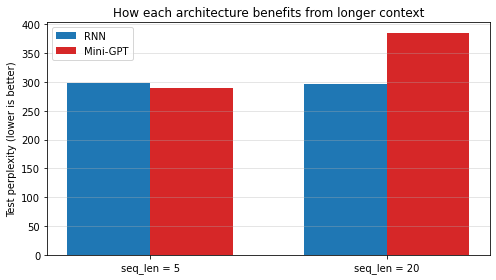


Going from seq_len=5 -> seq_len=20:
  RNN perplexity drop     : +3.2
  Mini-GPT perplexity drop: -95.3


In [12]:
context_lengths = [5, 20]

# Test-perplexity table:  results[model_name][seq_len] = perplexity
results = {'RNN': {}, 'GPT': {}}

for sl in context_lengths:
    tr_loader_sl, te_loader_sl = make_loaders(sl)

    print(f"\n--- seq_len = {sl} ---")

    rnn = RNNLanguageModel(vocab_size=VOCAB_SIZE)
    _, te = train(rnn, tr_loader_sl, te_loader_sl, n_epochs=1,
                  verbose=False, label=f"RNN sl={sl}")
    results['RNN'][sl] = np.exp(te[-1])
    print(f"  RNN test perplexity     : {results['RNN'][sl]:.1f}")

    gpt = MiniGPT(vocab_size=VOCAB_SIZE, embed_dim=48, n_heads=4,
                  n_layers=2, max_seq_len=sl)
    _, te = train(gpt, tr_loader_sl, te_loader_sl, n_epochs=1,
                  verbose=False, label=f"GPT sl={sl}")
    results['GPT'][sl] = np.exp(te[-1])
    print(f"  Mini-GPT test perplexity: {results['GPT'][sl]:.1f}")

# Plot the four results as a grouped bar chart
x = np.arange(len(context_lengths))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width / 2, [results['RNN'][sl] for sl in context_lengths],
        width, label='RNN', color='tab:blue')
plt.bar(x + width / 2, [results['GPT'][sl] for sl in context_lengths],
        width, label='Mini-GPT', color='tab:red')
plt.xticks(x, [f"seq_len = {sl}" for sl in context_lengths])
plt.ylabel('Test perplexity (lower is better)')
plt.title('How each architecture benefits from longer context')
plt.legend()
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Quantify the per-model improvement going from seq_len=5 to seq_len=20
rnn_gap = results['RNN'][5] - results['RNN'][20]
gpt_gap = results['GPT'][5] - results['GPT'][20]
print(f"\nGoing from seq_len=5 -> seq_len=20:")
print(f"  RNN perplexity drop     : {rnn_gap:+.1f}")
print(f"  Mini-GPT perplexity drop: {gpt_gap:+.1f}")

### What the long-context experiment shows

The result is counterintuitive at first: the Mini-GPT actually got *worse* going from `seq_len=5` to `seq_len=20` (perplexity 289 → 384), while the RNN was basically flat (299 → 296), exactly as in Module 2.

This is the same overfitting story from Section 10, viewed through a different lens. The number of training windows is basically the same at both context lengths (~182k either way) — what differs is the *richness* of each window. A length-5 window like `"the king is in his"` is generic; many similar phrasings appear throughout the corpus, so memorising any one of them isn't very useful. A length-20 window pins down specific 20-word phrasings, character names in context, dialogue tags — far more memorisable, far less reusable. The Mini-GPT's flexible attention happily commits the richer length-20 windows to memory, and its test perplexity suffers as a result. Longer context gives a *capacity-heavy* model more ways to memorise rather than more ways to generalise, on a small dataset like ours.

The textbook "Transformers benefit from longer context" claim is still true — but **it's a claim about behaviour at scale**, when you have enough data that memorising the training set isn't an option. On a corpus this small, longer context backfires for the Transformer. The RNN's fixed-size hidden state, much-criticised in principle, turns out to be an accidental regulariser here.

## 13. Architectural Reflection

We've seen two ways of building a language model:

**RNN**
- Sequential processing — one step at a time, slow to train
- $\mathcal{O}(\text{seq\_len})$ memory and compute per sequence
- Hidden state is a fixed-size bottleneck: all past information must squeeze through it
- Vanishing/exploding gradients limit how far back the model effectively remembers
- That fixed-size hidden state also acts as an *implicit regulariser* — it forces the model to compress information, which can actually help on small datasets

**Transformer (Mini-GPT)**
- Parallel processing across positions — much faster on GPU, modestly faster on CPU
- $\mathcal{O}(\text{seq\_len}^2)$ memory and compute per sequence (each pair of positions interacts)
- Every position can attend directly to every earlier position — no information bottleneck
- Gradients flow back through residual connections — no vanishing-gradient problem
- That same flexibility means **way more capacity to overfit** on small data — what's a regularisation drag on the RNN becomes a freedom-to-memorise on the Transformer

The quadratic scaling in `seq_len` is the Transformer's main computational weakness. It's why modern long-context models (>10,000 tokens) use various tricks (sparse attention, sliding-window attention, linear-attention approximations) to dodge the $\mathcal{O}(N^2)$ cost.

The Transformer-beats-RNN story that played out from 2017 onwards is fundamentally a *scale* story. The Transformer's architectural choices (no recurrence, no information bottleneck, freely-routed attention) trade *inductive bias for capacity*. With enough data — billions of tokens in modern training corpora — that trade pays off enormously, because the data itself constrains the model into learning real linguistic regularities. With ~180,000 tokens of Shakespeare, that trade doesn't pay off; you'd be better off with the more constrained RNN.

This is a real and important lesson: **architecture choice depends on data scale**. A model that wins on web-scale corpora can lose on a small training set — and vice versa.

## Summary

In this notebook we:

1. **Re-used** the Tiny Shakespeare data pipeline from Module 2 so the comparison would be apples-to-apples.
2. **Implemented causal self-attention** from scratch: Q/K/V projections, scaled dot-product, the causal mask, and multi-head attention.
3. **Built a Transformer block** with pre-LayerNorm, residual connections, and a feed-forward MLP.
4. **Stacked the blocks into a Mini-GPT** with learned token and positional embeddings, sized so that its parameter count is comparable to the RNN's.
5. **Re-built the RNN** from Module 2 so both models live in the same notebook.
6. **Trained both** under identical conditions and plotted their loss curves on the same axes. The Mini-GPT reached *lower training loss* but *higher test loss* than the RNN — the Transformer overfits faster on this small dataset.
7. **Compared generated text** from both models with greedy and temperature-based sampling. The two architectures produce qualitatively similar Shakespeare-like text.
8. **Ran a head-to-head experiment** on short vs. longer context windows. The Mini-GPT actually got *worse* with longer context, contrary to the textbook claim — again because more context gives a capacity-heavy model more ways to memorise this tiny training set.

The headline takeaway: **architecture choice depends on data scale**. Transformers' famous flexibility is an enormous advantage at web scale (billions of tokens) and a real liability at the Tiny Shakespeare scale (~180,000 tokens).

### Things to try
- Vary `n_heads` (e.g. 1, 2, 4) and `n_layers` (1, 2, 4) — how much do they help, and at what cost in parameters?
- Add `nn.Dropout(0.1)` inside `CausalSelfAttention` and `TransformerBlock`. Does the Mini-GPT's test loss improve?
- Replace the learned positional embeddings with **sinusoidal** ones (`sin(i/10000^(2k/d))`, `cos(i/10000^(2k/d))`). Does the model train differently?
- Visualise the attention weights for a specific input sequence — which earlier positions does the model attend to at each step?
- Increase the long-context experiment from `seq_len=20` to `seq_len=50` or `100` (warning: attention is quadratic in sequence length, so this gets expensive quickly).